# Vechta - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Vechta' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/045y6d111' -- 'Universität Vechta'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4283795089
1,not assigned,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4220992060
2,not assigned,Universität Vechta,U. of Vechta,https://openalex.org/W4286622681
3,not assigned,Universität Vechta,"Department of Geography, Faculty II, Universit...",https://openalex.org/W4283327789
4,not assigned,Universität Vechta,"Institute of Gerontology, University of Vechta...",https://openalex.org/W4229049335


In [47]:
MAPPING_DICT = {
    #'Bildung, Erziehung, Gesellschaft: Vechta-Institut für Inklusion': [],
    'Vechta Institute of Sustainability Transformation in Rural Areas': ['rural areas', 'sustainability transformation'],
    'Fakultät I': ['department of education', 'erziehungswissenschaften', 'gerontolog(ie|y)', 'soziale arbeit', 'education and social',
                   'psychology', '(faculty|department) (?<!i)i,', '(?<!natural and\s)(educational|soci(a|eta)l) science', 'social work', 
                   'gesellschaftswissenschaften', 'ethics', 'psychologie und pädagogik',
                   'economics and sustainability', 'pedagogy', 'inclusion', 'sociology', 'bildungsforschung'
                  ],
    'Fakultät II': ['germanisti(k|sch)', 'geography', 'geo(-|‐|\s)lab', 'biology', '(faculty|department) ii', 'sport',
                    'english', 'schulpädagogik', 'cultural (sciences|studies)', 'landschaftsökologie', 'landscape ecology',
                    'kulturwissenschaften', 'natur- und sozialwissenschaften', 'agriculture', 'media research', 'geschichte', 
                    'history', 'faculty of natural', 'training and movement', 'movement science'
                   ],
    'Zentrum für Lehrer*innenbildung': ['teacher training']
}

In [48]:
with open('./mapping_tables_fak/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [49]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [50]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [51]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4283795089
1,None,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4220992060
2,None,Universität Vechta,U. of Vechta,https://openalex.org/W4286622681
3,Fakultät II,Universität Vechta,"Department of Geography, Faculty II, Universit...",https://openalex.org/W4283327789
4,Fakultät I,Universität Vechta,"Institute of Gerontology, University of Vechta...",https://openalex.org/W4229049335
...,...,...,...,...
576,None,Universität Vechta,"Science Shop Vechta / Cloppenburg, University ...",https://openalex.org/W3158087746
577,Fakultät II,Universität Vechta,"Applied Physical Geography, Faculty II – Natur...",https://openalex.org/W3004183020
578,Fakultät I,Universität Vechta,"Chair of Business and Ethics, University of Ve...",https://openalex.org/W3005282337
579,Fakultät II,Universität Vechta,"Department of Sports Science, Faculty of Natur...",https://openalex.org/W3204200320


In [52]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Vechta, Germany', 'U. of Vechta',
       'University of Vechta, Vechta, Germany', 'University of Vechta',
       'University of Vechta Vechta Germany',
       'University of Vechta, Driverstraße 22, 49377, Vechta, Germany',
       'Universität , Vechta Germany',
       'University of Vechta, Driverstr. 22, 49364 Vechta, Germany',
       'University Vechta', 'University of Vechta Vechta, Germany',
       'University of Vechta , Vechta ,',
       'Universität Vechta Deutschland', 'Universität Vechta',
       'University of Vechta, 49377, Vechta, Germany',
       'University of Vechta, 49377 Vechta, Germany',
       'University of Vechta , Vechta , Germany',
       'University of Vechta , Vechta , Germany , TU Dresden , Dresden , Germany , Leipzig University , Leipzig , Germany',
       'Universität Vechta Driverstraße 22 49377 Vechta/D',
       'University of Vechta  Vechta Germany',
       'Universität Vechta Vechta Deutschland',
       'Universität Vechta  Drivers

In [53]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät I,150
1,Fakultät II,148
2,Vechta Institute of Sustainability Transformat...,33
3,Zentrum für Lehrer*innenbildung,2
4,NaN,248


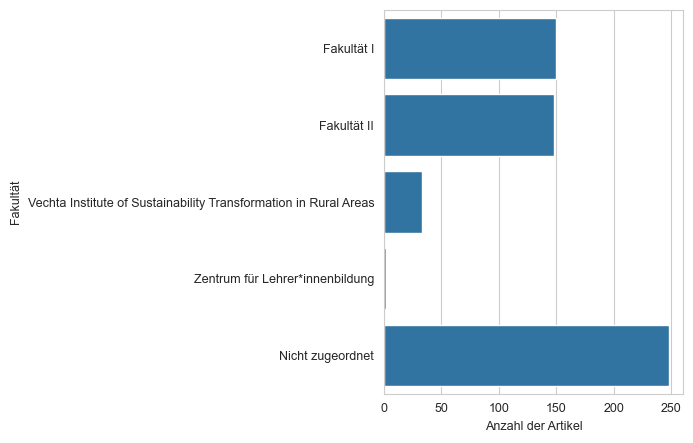

In [54]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [55]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5731497418244407

In [61]:
MAPPING_DICT_DEPT = {
    'Fakultät I': {
        'Fach Erziehungswissenschaften': ['erziehungswissenschaften', 'educational sciences', 'department of education', 'primary school'],
        'Fach Gerontologie': ['gerontolog(ie|y)'],
        'Fach Management sozialer Dienstleistungen': ['sozialer dienstleistungen', 'business (and )?ethics', 'social services management'],
        'Fach Soziale Arbeit': ['soziale arbeit', 'social work'],
        'Fach Soziologie': ['so(z|c)iolog(ie|y)'],
        'Fach Sustainability, Entrepreneurship and Innovation': ['entrepreneurship', 'sustainability'],
        'Lehr- und Forschungseinheit Pädagogische Psychologie': ['psycholog(ie|y)'],
    },
    'Fakultät II': {
        'Fach Anglistik': ['anglistik', 'english linguistics', 'department of english', 'english department'],
        'Fach Biologie': ['biolog(ie|y)'],
        'Fach Designpädagogik': ['designpädagogik'],
        'Fach Geographie': ['geograph(ie|y)', 'landscape', 'geo(-|‐|\s)lab', 'landschaftsökologie', 'agriculture'],
        'Fach Germanistik': ['germanisti(k|sch)'],
        'Fach Geschichtswissenschaft': ['geschichtswissenschaft', 'history', 'geschichte'],
        'Fach Katholische Theologie': ['katholische theologie', 'catholic'],
        'Fach Kulturwissenschaften': ['kulturwissenschaften', 'cultural (studies|sciences)', 'media research'],
        'Fach Mathematik': ['mathematik'],
        'Fach Musik': ['musi(k|c)'],
        'Fach Philosophie': ['philosoph(ie|y)'],
        'Fach Politikwissenschaft': ['politikwissenschaft'],
        'Fach Sachunterricht': ['sachunterricht', 'didaktik'],
        'Fach Sportwissenschaft': ['sport(s)?(\s)?science', 'sportwissenschaft', 'training and movement', 'movement science'],
    }
}

In [62]:
with open('./mapping_tables_dept/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [63]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [64]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II']['raw_affiliation_string'].apply(map_dept, 
                                                                        faculty='Fakultät II')

In [65]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät II') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Faculty of Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'Department II - Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'Faculty of Natural and Social Sciences, University of Vechta, Driverstraße 22, D-49377 Vechta, Germany',
       'University of Vechta, Faculty II',
       'Faculty II, University of Vechta, Vechta, Germany',
       'Faculty II, University of Vechta, Driverstr. 22, D-49377, Vechta, Germany',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Kreuzweg 3–5, 49377, Vechta, Deutschland',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Vechta, Deutschland'],
      dtype=object)

In [66]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Fach Anglistik,4
1,Fach Biologie,7
2,Fach Geographie,69
3,Fach Germanistik,15
4,Fach Geschichtswissenschaft,4
5,Fach Katholische Theologie,1
6,Fach Kulturwissenschaften,9
7,Fach Sachunterricht,2
8,Fach Sportwissenschaft,24
9,NaN,13


In [67]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
3,Fakultät II,Universität Vechta,"Department of Geography, Faculty II, Universit...",https://openalex.org/W4283327789,Fach Geographie
9,Fakultät II,Universität Vechta,"Dr. des. , Universität Vechta, Institut für Ge...",https://openalex.org/W4285414945,Fach Germanistik
11,Fakultät II,Universität Vechta,"Applied Physical Geography, Faculty II—Natural...",https://openalex.org/W4224068303,Fach Geographie
13,Fakultät II,Universität Vechta,"Department II â Applied Physical Geography, ...",https://openalex.org/W4281665769,Fach Geographie
14,Fakultät II,Universität Vechta,"Department II – Applied Physical Geography, Un...",https://openalex.org/W4281665769,Fach Geographie
...,...,...,...,...,...
559,Fakultät II,Universität Vechta,"Chair of Landscape Ecology, University of Vech...",https://openalex.org/W3030125167,Fach Geographie
571,Fakultät II,Universität Vechta,"University of Vechta, Institute for Sportscien...",https://openalex.org/W3175731670,Fach Sportwissenschaft
573,Fakultät II,Universität Vechta,"Faculty II—Geography, Institute for Spatial An...",https://openalex.org/W3166242612,Fach Geographie
577,Fakultät II,Universität Vechta,"Applied Physical Geography, Faculty II – Natur...",https://openalex.org/W3004183020,Fach Geographie


In [68]:
MAPPING_DICT_INST = {}

In [69]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Universität Vechta'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)